**1. Introduction & Problem Statement**

**Problem:** Banks and financial institutions face significant financial risk when a borrower defaults on a loan. The objective of this task is to build a Binary Classification Pipeline that automates the loan eligibility process. By analyzing applicant profiles, the system must predict whether a loan should be "Approved" (1) or "Rejected" (0) to minimize the bank's financial loss.

**2. Dataset Description**

The Loan Prediction Dataset (sourced from Kaggle) contains historical data of loan applicants. It is a "messy" real-world dataset requiring significant preprocessing.

Target Variable: Loan_Status (Y/N).

Key Features:

Demographics: Gender, Married, Dependents, Education, Self_Employed.

Financials: ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term.

Technical Challenge: The dataset contains missing values (nulls) and non-numeric categorical data that must be encoded before being processed by Logistic Regression and Decision Tree algorithms.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('loan_prediction.csv')

# 1. Display first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# 2. Check the data types and null counts
print("\n--- Dataset Info ---")
df.info()

# 3. Statistical summary
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 5 Rows ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

--- Statistical Summary ---


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [2]:
# 1. Fix the Dependents column (Replace '3+' with '3' and convert to numeric)
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# 2. Fill Missing Categorical Values (Mode)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# 3. Fill Missing Numerical Values (Median)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# Verify that all nulls are gone
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values After Cleaning ---
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_1498/2847532973.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_1498/2847532973.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

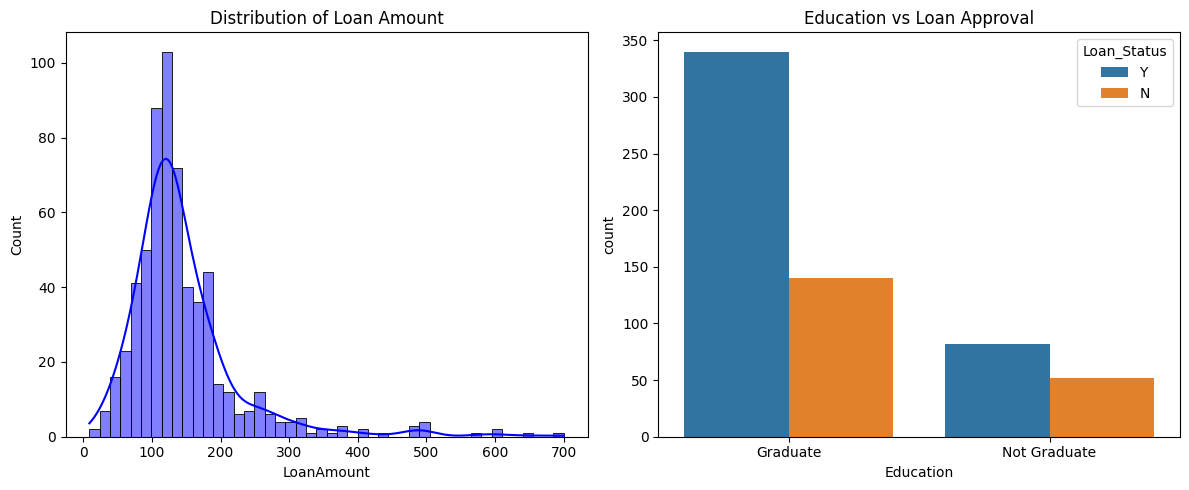

In [3]:
plt.figure(figsize=(12, 5))

# 1. Loan Amount Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['LoanAmount'], kde=True, color='blue')
plt.title('Distribution of Loan Amount')

# 2. Education vs Loan Status (Categorical)
plt.subplot(1, 2, 2)
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Approval')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Drop the ID column (it's useless for math)
df.drop('Loan_ID', axis=1, inplace=True)

# 2. Initialize LabelEncoder
le = LabelEncoder()

# 3. List of categorical columns to transform
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 4. Separate Features (X) and Target (y)
X = df.drop('Loan_Status', axis=1) # Everything except the answer
y = df['Loan_Status']              # The answer we want to predict

# 5. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data encoded and split successfully!")
print(f"Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Data encoded and split successfully!
Training rows: 491, Testing rows: 123


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Initialize the model
model = LogisticRegression(max_iter=5000)

# 2. Train the model (Fitting)
model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# 4. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 78.86%


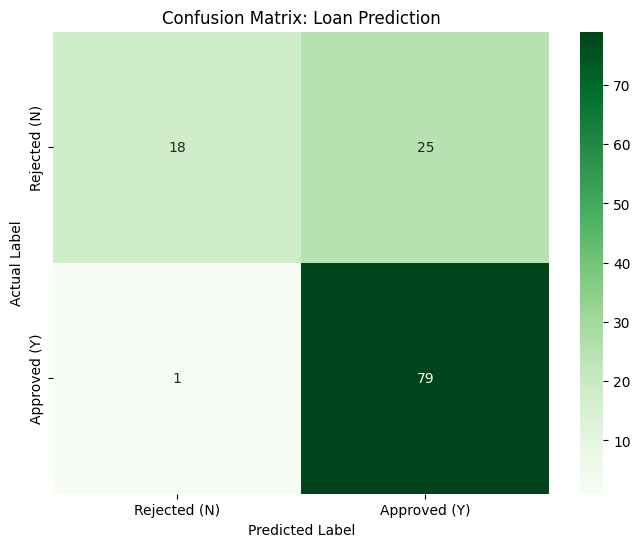


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Create the Confusion Matrix array
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it using Seaborn for better visuals
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Rejected (N)', 'Approved (Y)'],
            yticklabels=['Rejected (N)', 'Approved (Y)'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Loan Prediction')
plt.show()

# 3. Print the full report (Precision, Recall, F1-Score)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))